In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings
import lightgbm as lgb
import json
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
import networkx as nx           # For building and manipulating causal/knowledge graphs
import calendar
import pickle


from eventregistry import *     # Event Registry API for fetching news articles
from IPython.display import display, Markdown
from IPython.display import display
from datetime import timedelta
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from datetime import datetime
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from ta.trend import MACD, SMAIndicator           # Technical analysis indicators
from ta.momentum import RSIIndicator, ROCIndicator
from ta.volatility import BollingerBands
from typing import Optional, List, Tuple, Dict, Any
from dotenv import load_dotenv
from datetime import datetime, timedelta
from openai import OpenAI        # OpenAI client for GPT-based causal extraction
from pyvis.network import Network # Interactive graph visualization (HTML output)
from IPython.display import SVG, display
import sys
from pathlib import Path


# Ignore all warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Set display options so we can see all columns and enough rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')



# Set display options (repeated for consistency after style changes)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.5,
})


# ─────────────────────────────────── Import custom methods that I have implemented  ──────────────────────────────────────────
try:
    from utils.internal_methods import visualize_important_features
    from utils.internal_methods import visualize_knowledge_graph
    from utils.internal_methods import build_unified_graph, visualize_unified_graph, visualize_events_in_time_window
except ModuleNotFoundError:
    # Make sure project root (or its parent) is on sys.path
    for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        if (base / "utils").exists():
            sys.path.insert(0, str(base))
            break
    from utils.internal_methods import visualize_important_features
    from utils.internal_methods import visualize_knowledge_graph
    from utils.internal_methods import build_unified_graph, visualize_unified_graph, visualize_events_in_time_window


# ── Global constants ────────────────────────────────────────────────────────
FORECAST_HORIZONS = [1, 7, 14, 30]  # Days ahead to forecast
TEST_SIZE_DAYS = 30                  # Last 30 days reserved for testing
RANDOM_STATE = 42                    # Reproducibility seed
LSTM_LOOKBACK = 14                   # LSTM sequence length (14 days)
MODEL_DIR = '../models'              # Directory where trained models are saved

# Seed all random number generators for reproducibility
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create model directory if it doesn't exist
# os.makedirs(MODEL_DIR, exist_ok=True)

# ── Load API keys from .env file ────────────────────────────────────────────
# These keys are needed for:
#   - OpenAI: LLM-based causal triplet extraction (GPT-5-mini / GPT-5)
#   - Groq: Alternative LLM provider (not used in current pipeline)
#   - Event Registry: Fetching news articles about supply chain events
load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")
event_registry = os.getenv("EVENT_REGISTRY")
my_openai_api_key = os.getenv("MY_OPENAI_API_KEY")


print("✓ Imports complete")

✓ Imports complete


<br> <br>


## Load sub Causal Graph & Event Graph

In [2]:
date = "20260402"
time = "121459"
row_number = 548

sub_causal_graph_importance_df = pd.read_csv(f"../importance_df/importance_df_{row_number}.csv")
sub_causal_graph_svg = f"../causal_graph/sub_causal_graph/sub_causal_graph_{row_number}.svg"
sub_causal_graph_csv = pd.read_csv(f"../causal_graph/sub_causal_graph/sub_causal_graph_{row_number}.csv")
feature_impoprtance = f"../xai/feature_importance_top20_{row_number}.svg"
enriched_kg = pd.read_csv(f"../enriched_knowledge_graph/enriched_kg_{date}_{time}_{row_number}.csv")
row = pd.read_csv(f"../rows/row_{row_number}.csv")
X_test = pd.read_csv('../../data/FinalDataset/X_test.csv', index_col=0)

<br> <br>

### Visualize the feature importance

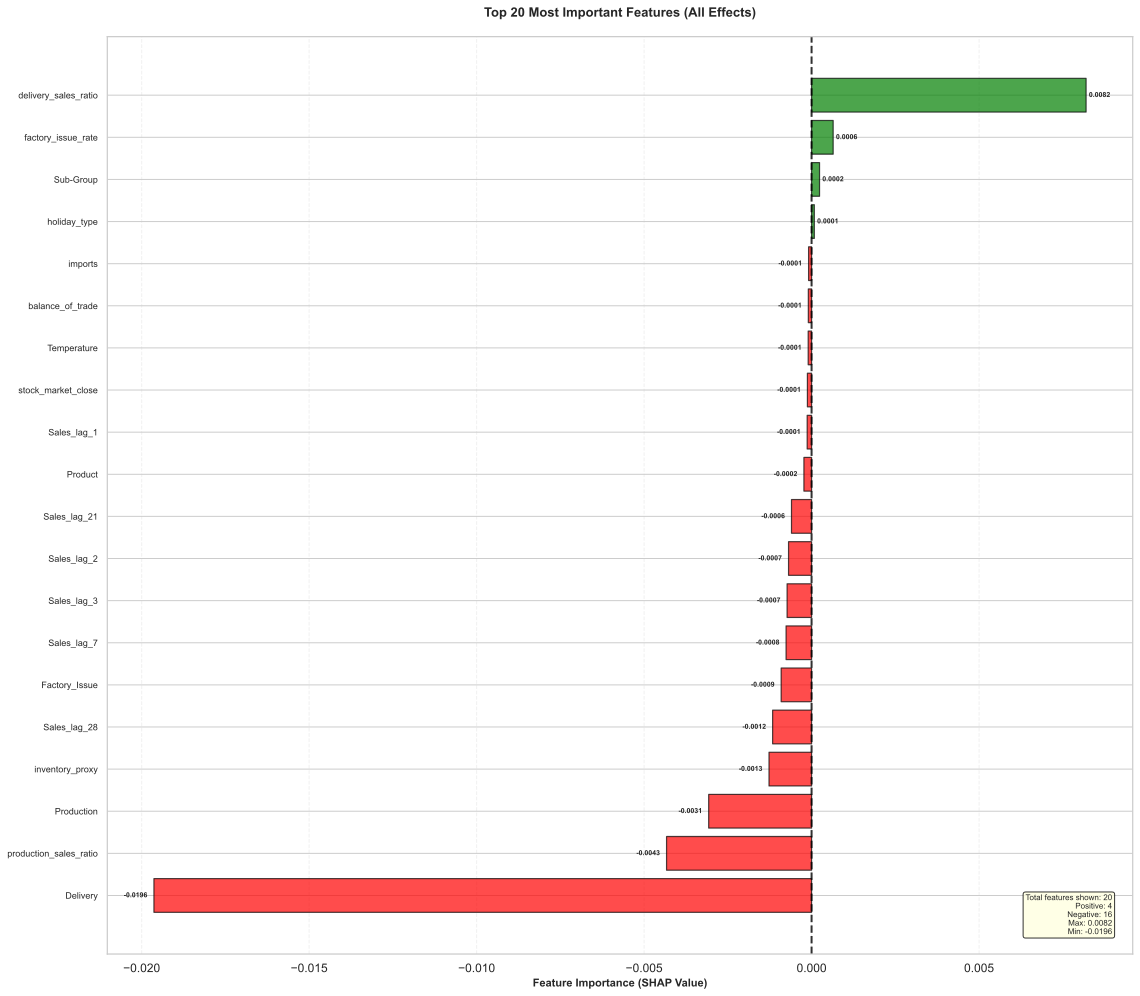

In [3]:
if os.path.exists(feature_impoprtance):
    display(SVG(filename=feature_impoprtance))
else:
    visualize_important_features(sub_causal_graph_importance_df, top_n=20, effect_type='both', figsize=(16, 14), fontsize=9)

<br> <br>

### Visualize sub causal graph

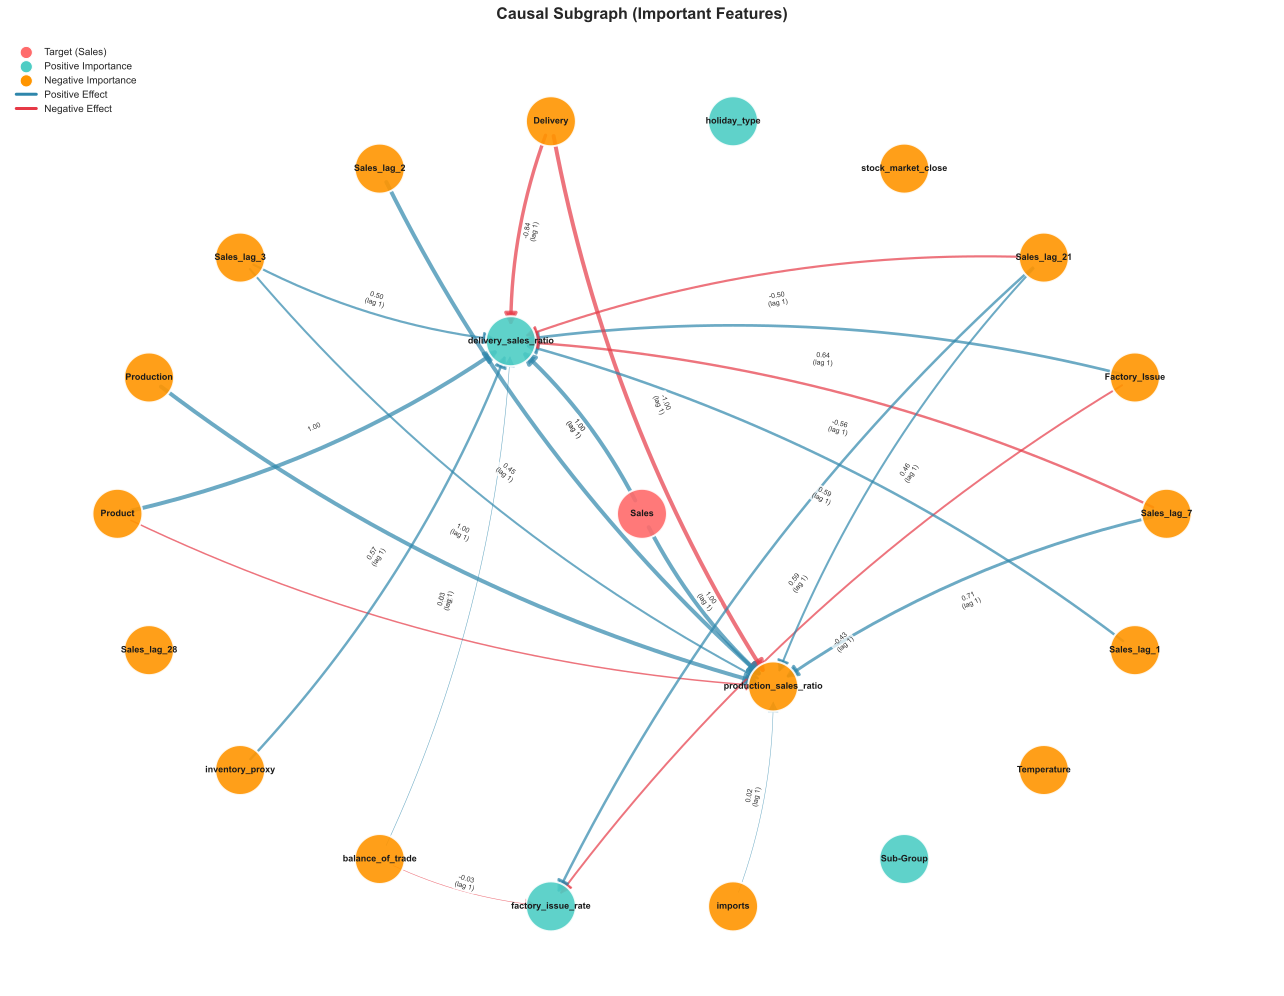

In [4]:
if os.path.exists(sub_causal_graph_svg):
    display(SVG(filename=sub_causal_graph_svg))
else:
    print(f"File not found: {sub_causal_graph_svg}")

<br> <br>

#### Macroeconomic features and their relationship existed in the sub causal graph

In [5]:
def filter_sub_causal_graph_by_features(clean_sub_causal_graph, enriched_kg_df):
    feature_set = set(enriched_kg_df["feature"].dropna())
    mask = (clean_sub_causal_graph["source"].isin(feature_set) | clean_sub_causal_graph["target"].isin(feature_set))
    return clean_sub_causal_graph.loc[mask].reset_index(drop=True)


# Example usage in your notebook:
filtered_sub_causal_graph_df = filter_sub_causal_graph_by_features(
    sub_causal_graph_csv.drop(columns=["Unnamed: 0"]),
    enriched_kg
)

filtered_sub_causal_graph_df

,source,target,weight
0,balance_of_trade,delivery_sales_ratio,0.033258
1,balance_of_trade,factory_issue_rate,-0.032606
2,imports,production_sales_ratio,0.018085


## Visualize the event graph

In [6]:
# ── Example usage ────────────────────────────────────────────────────────────
# Available themes :  "light"  |  "dark"  |  "pastel"  |  "highcontrast"
# Edge label styles:  "text"   |  "rectangle"  |  "roundrect"  |  "ellipse"  |  "circle"  |  "diamond"

visualize_knowledge_graph(
    df=enriched_kg,
    output_file=f"../kg_visualization/refined_triplet_kg_{date}_{time}_{row_number}.html",
    theme="highcontrast",                 # white background, readable colours
    node_size=25,                  # uniform node radius (px)
    node_font_size=14,             # node label font size (px)
    edge_font_size=12,             # edge label font size (px)
    edge_label_style= "roundrect"  #"text",    # plain text (no shape behind label)
)

Parsed 80 triplets from 80 rows
Interactive graph saved to: ../kg_visualization/refined_triplet_kg_20260402_121459_548.html
  Theme: highcontrast  |  Nodes: 76  |  Edges: 73
  Node size: 25  |  Node font: 14px  |  Edge font: 12px
  Edge label style: roundrect  |  Label padding: 5px
  Categories: Currency Movement, Global Shock, Government Policy, Industry Activity, Infrastructure, Market Dynamics, Monetary Policy, Trade Policy


'../kg_visualization/refined_triplet_kg_20260402_121459_548.html'

<br> <br>

### Query the Event graph

#### The complete graph

In [7]:
cols = ["url","title", "date", "feature", "refined_triplet", "attribute"]

enriched_kg[cols]

,url,title,date,feature,refined_triplet,attribute
0,https://www.aninews.in/news/world/asia/banglad...,Bangladesh may overtake China to be EU's bigge...,2023-01-24,imports,(Work Orders Shift to Bangladesh) ── decrease ...,"""Work Orders Shift: Market Dynamics"""
1,https://asianews.network/overcoming-looming-ec...,Overcoming looming economic challenges in 2023,2023-01-10,imports,(High Import Growth) ── increase ──> (imports),"""High Import Growth: Market Dynamics"""
2,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Government boosts consumer imports) ── increa...,"""Government boosts consumer imports: Governmen..."
3,https://www.bssnews.net/business/120673,Businessmen will be happy seeing next budget: ...,2023-04-13,imports,(AIT Reduction at Import Stage) ── decrease ──...,"""AIT Reduction at Import Stage: Government Pol..."
4,https://www.irishsun.com/news/273832902/bangla...,Bangladesh government should think twice befor...,2023-05-16,imports,(Yuan Payments in Bangladesh) ── increase ──> ...,"""Yuan Payments: Currency Movement"""
5,https://hr.asia/media-outreach/dhl-global-forw...,DHL Global Forwarding expands its dedicated Co...,2023-05-02,imports,(Port Expansion Speeding Shipping) ── increase...,"""Port Expansion: Infrastructure"""
6,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Huge Imports) ── increase ──> (imports),"""Huge Imports: Market Dynamics"""
7,https://www.bssnews.net/district/116749,Essential Commodities now available at stable ...,2023-03-21,imports,(Huge Imports) ── increase ──> (imports),"""Huge Imports: Trade Policy"""
8,https://www.hellenicshippingnews.com/commodity...,Commodity Tracker: 5 charts to watch this week,2023-06-20,imports,(Bangladesh's SPM facility) ── increase ──> (i...,"""SPM facility: Infrastructure"""
9,https://www.msn.com/en-xl/asia/bangladesh/doll...,Dollar crisis casts a shadow over operation of...,2023-02-17,imports,(Dollar Crisis at Rampal Plant) ── decrease ──...,"""Dollar Crisis: Currency Movement"""


<br> <br> <br>
 
#### Filtering the graph

In [8]:
mac_evgr_feature = "balance_of_trade"  # macroeconimic feature in event graph

balance_of_trade_rows = enriched_kg.loc[enriched_kg["feature"] == mac_evgr_feature].reset_index(drop=True)
balance_of_trade_rows[cols]

,url,title,date,feature,refined_triplet,attribute
0,https://www.kenyastar.com/news/273832902/bangl...,Bangladesh government should think twice befor...,2023-05-16,balance_of_trade,(Yuan Use for Imports) ── improve ──> (balance...,"""Yuan Use for Imports: Currency Movement"""
1,https://www.europesun.com/news/273832902/bangl...,Bangladesh government should think twice befor...,2023-05-16,balance_of_trade,(Yuan Use in Trade) ── deteriorate ──> (balanc...,"""Yuan Use in Trade: Currency Movement"""
2,https://www.bssnews.net/national-budget-2023-2...,Govt aims to sustain economic recovery: Kamal ...,2023-06-01,balance_of_trade,(Russia-Ukraine War Impact) ── deteriorate ──>...,"""Russia-Ukraine War Impact: Global Shock"""
3,https://www.bssnews.net/business/104238,"Govt focusing on signing PTAs, FTAs considerin...",2023-01-09,balance_of_trade,(LDC Graduation Tariff Loss) ── deteriorate ──...,"""LDC Graduation Tariff Loss: Trade Policy"""
4,https://www.polandsun.com/news/273832902/bangl...,Bangladesh government should think twice befor...,2023-05-16,balance_of_trade,(Yuan Trade Shift) ── deteriorate ──> (balance...,"""Yuan Trade Shift: Trade Policy"""


<br> <br>

## Combine the Event Graph and Causal Graph

In [9]:
unified_graph_df = build_unified_graph(filtered_sub_causal_graph_df, enriched_kg)
unified_graph_df

,source,relation,target,edge_type,weight,date,title,attribute
0,Yuan Use for Imports,improve,balance_of_trade,event,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use for Imports: Currency Movement"""
1,balance_of_trade,has_attribute,Currency Movement,attribute,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use for Imports: Currency Movement"""
2,Yuan Use in Trade,deteriorate,balance_of_trade,event,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use in Trade: Currency Movement"""
3,balance_of_trade,has_attribute,Currency Movement,attribute,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Yuan Use in Trade: Currency Movement"""
4,Russia-Ukraine War Impact,deteriorate,balance_of_trade,event,NaN,2023-06-01,Govt aims to sustain economic recovery: Kamal ...,"""Russia-Ukraine War Impact: Global Shock"""
...,...,...,...,...,...,...,...,...
163,Sugar Import Costs,decrease,imports,event,NaN,2023-02-28,Bangladesh Withdraws Duty On Sugar Import To S...,"""Sugar Import Costs: Market Dynamics"""
164,imports,has_attribute,Market Dynamics,attribute,NaN,2023-02-28,Bangladesh Withdraws Duty On Sugar Import To S...,"""Sugar Import Costs: Market Dynamics"""
165,Shortage of Greenbacks,decrease,imports,event,NaN,2023-01-20,"Money or no money, crisis persists","""Shortage of Greenbacks: Currency Movement"""
166,imports,has_attribute,Currency Movement,attribute,NaN,2023-01-20,"Money or no money, crisis persists","""Shortage of Greenbacks: Currency Movement"""


In [10]:
# display_mode: "all" | "event" | "causal"
# show_edge_labels: True | False

now = datetime.now()
current_date = now.strftime("%Y%m%d")   
current_time = now.strftime("%H%M%S")   

display_mode = "all"

match display_mode:
    case "all":
        output_file = f"../unified_causal_event_graph/unified_causal_event_graph_{current_date}_{current_time}_{row_number}_all.html"
    case "event":
        output_file = f"../unified_causal_event_graph/unified_causal_event_graph_{current_date}_{current_time}_{row_number}_event.html"
    case "causal":
        output_file = f"../unified_causal_event_graph/unified_causal_event_graph_{current_date}_{current_time}_{row_number}_causal.html"
    case _:
        output_file = f"../unified_causal_event_graph/unified_causal_event_graph_{current_date}_{current_time}_{row_number}_all.html"


visualize_unified_graph(
    unified_df=unified_graph_df,
    output_file= output_file, # f"../unified_causal_event_graph/unified_causal_event_graph_{current_date}_{current_time}_{row_number}.html",
    display_mode=display_mode, # "causal",
    show_edge_labels=True, # True, 
    theme="pastel", # ["light", "dark", "pastel", "highcontrast"]
    node_size=25,
    node_font_size=14,
    edge_font_size=12,
    edge_label_style="roundrect",
)

Unified causal+event graph saved to: ../unified_causal_event_graph/unified_causal_event_graph_20260407_114320_548_all.html
  Display mode: all  |  Theme: pastel  |  Nodes: 84  |  Edges: 85
  Event edges: 78  |  Causal edges: 3  |  Attribute edges: 87
  Node size: 25  |  Node font: 14px  |  Edge font: 12px
  Edge label style: roundrect  |  Label padding: 5px
  Categories: Causal Feature, Currency Movement, Global Shock, Government Policy, Industry Activity, Infrastructure, Market Dynamics, Monetary Policy, Trade Policy


'../unified_causal_event_graph/unified_causal_event_graph_20260407_114320_548_all.html'

<br> <br> <br>

## Apply timing

<br> <br> 

Find the same row that is in X_test. We need to this in order to have access to the date

In [ ]:
display(Markdown("### Random Row\n\n"))
display(row)


row_features = row.drop(columns=["Unnamed: 0", "actual", "predicted", "residual"], errors="ignore")
common_cols = [c for c in X_test.columns if c in row_features.columns]

candidate = row_features.iloc[0][common_cols]

numeric_cols = X_test[common_cols].select_dtypes(include=[np.number]).columns
mask = pd.Series(True, index=X_test.index)

if len(numeric_cols) > 0:
    mask &= np.isclose(
        X_test[numeric_cols].to_numpy(),
        candidate[numeric_cols].to_numpy(),
        rtol=1e-6,
        atol=1e-8
    ).all(axis=1)

for col in [c for c in common_cols if c not in numeric_cols]:
    mask &= X_test[col].eq(candidate[col])

matched_row = X_test.loc[mask]

display(Markdown("### X_test Row\n\n"))
display(matched_row)

### Random Row



,Unnamed: 0,Product,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,production_sales_ratio,delivery_sales_ratio,factory_issue_rate,inventory_proxy,interest_rate_value,stock_market_close,inflation_rate,balance_of_trade,exports,imports,currency_log_return,currency_momentum_5d,actual,predicted,residual
0,Sample_1 (idx=548),18,0.025982,0.035683,0.004752,3,12,2,13,0.0,0.52381,0.587302,0.884058,4,6,0.0,0.007829,0.005675,0.006735,0.001538,0.018016,0.0,0.007521,2.36715,0.425121,1.428571,0.617673,0.0,0.993405,0.817518,0.0,1.0,1.0,0.569523,0.67644,0.007077,0.005286,0.001791


### X_test Row



,Date,Product,Production,Factory_Issue,Delivery,Group,Sub-Group,holiday_type,holiday_name,Rainfall,Sunshine,Humidity,Temperature,category,scope_or_location,typical_rain_mm,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,production_sales_ratio,delivery_sales_ratio,factory_issue_rate,inventory_proxy,interest_rate_value,stock_market_close,inflation_rate,balance_of_trade,exports,imports,currency_log_return,currency_momentum_5d
4177,2023-07-19,18,0.025982,0.035683,0.004752,3,12,2,13,0.0,0.52381,0.587302,0.884058,4,6,0.0,0.007829,0.005675,0.006735,0.001538,0.018016,0.0,0.007521,2.36715,0.425121,1.428571,0.617673,0.0,0.993405,0.817518,0.0,1.0,1.0,0.569523,0.67644


In [ ]:

days_back = 35

path, df_event_in_time = visualize_events_in_time_window(
    unified_df=unified_graph_df,
    reference_date=matched_row["Date"],   # 2023-07-19
    days_back=days_back,                          # show events from 40 days before
    output_file=f"../event_time_window/events_{row_number}_{days_back}d.html",
    theme="pastel",
    edge_label_style="roundrect",
)


Event time-window graph saved to: ../event_time_window/events_548_35d.html
  Reference date: 2023-07-19  |  Window: 35 days back  (from 2023-06-14)
  Event edges: 4  |  Attribute edges: 3  |  Nodes: 8
  Theme: pastel


In [ ]:
filtered_sub_causal_graph_df